In [2]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from Matriz_multiclase import plot_confusion_multiclase
from Matriz_binaria import binary_confusion_metrics_save

In [3]:
ruta = "Seed_limpio.csv"
df = pd.read_csv(ruta)
df.head()

,Area,Perimeter,Compactness,Length_kernel,Width_kernel,Asymmetry_coeff,Length_groove,Class
0,0.242682,0.291322,0.527223,0.312500,0.245902,0.011702,0.264402,0
1,0.532578,0.572314,0.697822,0.547860,0.600143,0.390578,0.690793,1
2,0.417375,0.485537,0.522686,0.501126,0.438346,0.133391,0.237322,0
3,0.388102,0.371901,0.972777,0.172297,0.595866,0.130271,0.064008,0
4,0.018886,0.107438,0.023593,0.235360,0.012830,0.610709,0.332349,2


## Se hara una SVM

In [4]:
# Separar variables
X = df.drop("Class", axis=1)
y = df["Class"]

# Separar conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado de características (muy importante para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Entrenar la SVM

In [5]:
# Crear el modelo SVM con kernel RBF (recomendado)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Entrenar
svm.fit(X_train_scaled, y_train)

SVC(random_state=42)

## Evaluar el modelo

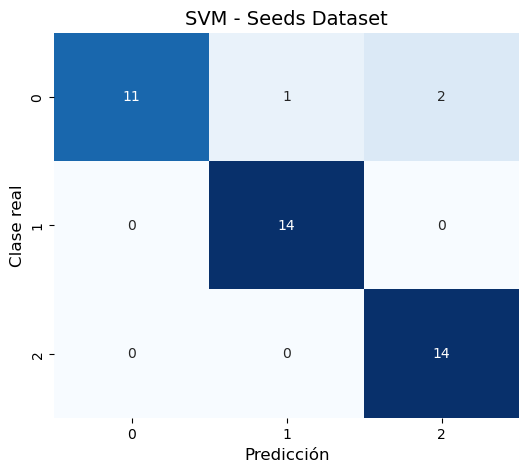


Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       0.93      1.00      0.97        14
           2       0.88      1.00      0.93        14

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



In [6]:
plot_confusion_multiclase(svm, X_test_scaled, y_test, title="SVM - Seeds Dataset")

## Optimizar con Grid Search

In [7]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor exactitud:", grid.best_score_)


Mejores parámetros: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Mejor exactitud: 0.9338680926916221


## Evaluar el mejor modelo

In [8]:
best_svm = grid.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

print("Exactitud final:", best_svm.score(X_test_scaled, y_test))


Exactitud final: 0.9761904761904762


## Matrices binarias

In [10]:
binary_confusion_metrics_save(svm, X_test_scaled, y_test)

Se guardaron las matrices de confusión en la carpeta: matrices_confusion


,Clase,TP,TN,FP,FN,Accuracy,Balanced_Acc,Precision,Recall,Specificity,F1,MCC,ROC_AUC,Support
0,0,11.0,28.0,0.0,3.0,0.928571,0.892857,1.0,0.785714,1.0,0.88,0.842424,0.892857,14
1,1,14.0,27.0,1.0,0.0,0.97619,0.982143,0.933333,1.0,0.964286,0.965517,0.948683,0.982143,14
2,2,14.0,26.0,2.0,0.0,0.952381,0.964286,0.875,1.0,0.928571,0.933333,0.901388,0.964286,14
3,Macro,NaN,NaN,NaN,NaN,0.952381,0.946429,0.936111,0.928571,0.964286,0.926284,0.897498,0.946429,NaN
4,Micro,NaN,NaN,NaN,NaN,0.952381,0.946429,0.928571,0.928571,0.964286,0.928571,NaN,NaN,42
5,Weighted,NaN,NaN,NaN,NaN,0.952381,0.946429,0.936111,0.928571,0.964286,0.926284,0.897498,0.946429,NaN
